# Homework 3

We used Google Colab for GPU access and were able to train about 9 different models. The
first 3 used 600 gradient steps, then 10,000, and finally 100,000. For each set of 
gradient steps, we trained three different models - that were moderately different in
terms of architecture, so we could figure out what directions to push the model so it 
would "learn language". Following table is a quick summary:

| Run ID | Size | 
| ------ | ---- |
| init-600 | small |
| init-600 | base |
| init-600 | large |
| base-10k | small |
| base-10k | base |
| base-10k | large |
| long-100k | small | 
| long-100k | base | 
| long-100k | large | 

For most of the notebook below, we used the base with 100k gradient steps as the demo
model, except for part (g), where we experimented with a variety of different 
architectures

From a code perspective, we prefer modular development, so we had files for each part
of the process. All is pasted at the bottom in the Appendix. 

In [12]:
import re 
import json 

import pandas as pd 
import torch 
from IPython import Image

from config import (
    DataConfig,
    GlobalTrainingConfig,
    RunConfig,
    TokenConfig,
    TokenizationConfig,
    ModelConfig
)
from models import TokenChunkDataset
from tokenizer import build_token_memmap, build_tokenizer, iter_stories, count_tokens
from training import train_model
from utils import save_json

The config objects make our life a lot easier – one central place to manage all the 
different configuration values

In [ ]:
token_config = TokenConfig()
data_config = DataConfig()
global_training_config = GlobalTrainingConfig()
tokenization_config = TokenizationConfig()
run_config = RunConfig("long-100000")

## (a) Tokenizer

We trained a BPE tokenizer with vocabulary size 3,000 on the first 1,000,000 training 
stories. BPE starts from a small inventory of characters or character-like pieces and 
repeatedly merges frequent adjacent pairs, so common fragments become single tokens 
while rare words still fall back to smaller subwords. This is preferable to pure 
character tokenization because the sequence length becomes much shorter, and it is 
preferable to full word tokenization because rare words and misspellings can still be 
represented without an exploding vocabulary.

For this notebook we used a metaspace BPE setup so spaces are preserved on decode, and 
we reserved the special tokens `<pad>`, `<bos>`, `<eos>`, and `<unk>`.

We also printed out 5 sentences from the first story, looked at the word count vs. token 
count, to see what tokens the tokenizer was picking up. The outputs are below

In [14]:
# build_tokenizer will load the tokenizer if we already trained it
tokenizer = build_tokenizer(
    tokenization_config, token_config, data_config.training_file_local
)

for item in iter_stories(tokenization_config, data_config.training_file_local):
    sentences = re.split(r"[.\n!?]+", item)
    for sentence in sentences[:5]:
        word_count = len(sentence.split(" "))
        encodings = tokenizer.encode(sentence)
        print(f"{sentence} has {word_count} words and {len(encodings)} tokens:")
        print(f"  {tuple(zip(encodings.tokens, encodings.ids))}")

Once upon a time there was a little boy named Ben has 11 words and 11 tokens:
  (('▁Once', 363), ('▁upon', 372), ('▁a', 191), ('▁time', 656), ('▁there', 336), ('▁was', 215), ('▁a', 191), ('▁little', 326), ('▁boy', 446), ('▁named', 337), ('▁Ben', 480))
 Ben loved to explore the world around him has 9 words and 8 tokens:
  (('▁Ben', 480), ('▁loved', 442), ('▁to', 198), ('▁explore', 1651), ('▁the', 195), ('▁world', 1630), ('▁around', 565), ('▁him', 414))
 He saw many amazing things, like beautiful vases that were on display in a store has 16 words and 20 tokens:
  (('▁He', 249), ('▁saw', 319), ('▁many', 607), ('▁amazing', 2158), ('▁thing', 509), ('s,', 464), ('▁like', 455), ('▁beautiful', 996), ('▁v', 624), ('as', 501), ('es', 329), ('▁that', 318), ('▁were', 341), ('▁on', 291), ('▁dis', 1245), ('pl', 786), ('ay', 212), ('▁in', 246), ('▁a', 191), ('▁store', 1338))
 One day, Ben was walking through the store when he came across a very special vase has 17 words and 17 tokens:
  (('▁One', 378

The above print / display statements illustrate the tokenization process on the first five sentences of the first story

## (b) Create the dataset

We concatenated tokenized stories into one long stream, appending <eos> after every story, and then chunked that stream into non-overlapping windows of length 128. For each chunk, the input is tokens t_0, ..., t_{L-1} and the target is the same chunk shifted by one position, which implements standard next token prediction.

The results were:
- **Train:** Train has 37781992 tokens and 295171 samples
- **Validation:** Train has 5184076 tokens and 40500 samples

In [16]:
train_token_count = count_tokens(
    tokenization_config, tokenizer, data_config.training_file_local
)
valid_token_count = count_tokens(
    tokenization_config, tokenizer, data_config.validation_file_local
)

train_token_memmap_path = build_token_memmap(
    tokenization_config,
    token_config,
    tokenizer,
    data_config.training_file_local,
    train_token_count,
)
valid_token_memmap_path = build_token_memmap(
    tokenization_config,
    token_config,
    tokenizer,
    data_config.validation_file_local,
    valid_token_count,
)

training_samples = int(train_token_count / global_training_config.context_length)
display(f"Train has {train_token_count} tokens and {training_samples} samples")

validation_samples = int(valid_token_count / global_training_config.context_length)
display(f"Validation has {valid_token_count} tokens and {validation_samples} samples")

'Token count for stories is 189162345'

'Output train memmap at /Users/sanch/Obsidian/2025-spring/Notes/242B/Homeworks/hw3/artifacts/tokenizers/train_tokens_metaspace_1000000_v3000.bin'

PosixPath('/Users/sanch/Obsidian/2025-spring/Notes/242B/Homeworks/hw3/artifacts/tokenizers/valid_tokens_metaspace_1000000_v3000.bin')

## (c) Model

We used a pre norm decoder only transformer with sinusoidal positional encoding and tied
input/output embeddings. The data flow is:

Input token IDs
→ Token embedding
→ + Sinusoidal position encoding
→ Transformer blocks (causal self-attention + feed-forward)
→ Final layer norm
→ Tied output projection
→ Next token logits

Each transformer block uses multi-head causal self attention with 
`scaled_dot_product_attention(..., is_causal=True)`, followed by a GELU feed forward 
network, residual connections, and layer normalization. Weight tying means the output 
projection reuses the token embedding matrix, which is standard in language models and 
keeps the parameter count lower.

In [20]:
configs = [
    ModelConfig(
        name="base",
        d_model=160,
        n_heads=5,
        n_layers=4,
        d_ff=480,
        batch_size=16,
        learning_rate=3e-4,
        weight_decay=0.1,
        warmup_steps=80,
        max_steps=10000,
        use_amp=torch.cuda.is_available(),
    ),
]

## (d) Training

The first run we did was only about 600 steps, and the model made absolutely no sense. 
So, we scaled it in the next attempt up to 10,000. The validation loss continued to 
decrease through 10,000 steps, although with diminishing returns. This suggests the 
models are still learning and may benefit from additional training. However, the 
generated text remains only partially coherent, indicating that while next-token 
prediction improves steadily, generation quality is still limited by model capacity 
and/or training budget.

### But, all was not hopeless

While the sentences were still not that coherent, there was marked improvement from the 
initial step count of 600. It learned:

- Plausible sentence structure
- Recognizable TinyStories motifs
- Local grammar (up to 4 neighboring words)

What was broken was mostly:

- Entity and pronoun consistency: The first sentence introduced Tom, but the second 
  sentence started with Jill
- Event logic: Unprompted events would happen
- Semantic coherence over longer spans

So, we gave it another shot but this time with 100,000 gradient steps.

### 100,000 gradient steps

- The training / validation loss clearly indicates that the previous 10k model was
undertrained
- The `small` model plateaued higher, which is what we'd hope to see
- `base` performed surprisingly well, comparable to the `large` model

All of them achieved a loss of about ~2.7, which is a lot better than the ~4.5 at 10k

### Other Information

- We implemented a cosine decay for the learning rate decay
- Throughout the training process, we ended up saving the step-level losses and 
  perplexity values
- For validation, we ran validation comparisons every 100 or 1000 steps (depending on 
the modes size), and saved to JSON
- The initial loss we got across all models was around 8.02 - 8.03, which is about equal
to ln(3000), where 3000 is our vocabulary count. 
- The below code is training our top 3 models by performance, and plotting the training 
and validation loss curves

In [25]:
train_dataset = TokenChunkDataset(
    train_token_memmap_path, train_token_count, global_training_config.context_length
)
valid_dataset = TokenChunkDataset(
    valid_token_memmap_path, valid_token_count, global_training_config.context_length
)

# create the results object 
results: dict[str, dict] = {}

# use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for config in configs:
    metrics_path = run_config.metrics / f"{config.name}.json"
    if metrics_path.exists():
        results[config.name] = json.loads(metrics_path.read_text(encoding="utf-8"))
        continue
    result = train_model(
        run_config,
        global_training_config,
        config,
        tokenizer,
        train_dataset,
        valid_dataset,
        device=device,
    )
    results[config.name] = result
    save_json(result, metrics_path)

    if device.type == "cuda":
        torch.cuda.empty_cache()

[small] Step 1 has loss 8.05
[small] Step 2 has loss 8.06
[small] Step 3 has loss 8.06
[small] Step 4 has loss 8.06
[small] Step 5 has loss 8.05
[small] Step 6 has loss 8.05
[small] Step 7 has loss 8.04
[small] Step 8 has loss 8.05
[small] Step 9 has loss 8.03
[small] Step 10 has loss 8.02
[small] Step 11 has loss 8.02
[small] Step 12 has loss 8.01
[small] Step 13 has loss 8.00
[small] Step 14 has loss 8.00
[small] Step 15 has loss 7.99
[small] Step 16 has loss 7.99
[small] Step 17 has loss 7.96
[small] Step 18 has loss 7.95
[small] Step 19 has loss 7.96
[small] Step 20 has loss 7.94
[small] Step 21 has loss 7.93
[small] Step 22 has loss 7.91
[small] Step 23 has loss 7.90
[small] Step 24 has loss 7.89
[small] Step 25 has loss 7.87
[small] Step 26 has loss 7.85
[small] Step 27 has loss 7.84
[small] Step 28 has loss 7.82
[small] Step 29 has loss 7.81
[small] Step 30 has loss 7.78
[small] Step 31 has loss 7.75
[small] Step 32 has loss 7.75
[small] Step 33 has loss 7.75
[small] Step 34 has

Here's the results / summary of the three models we ran

In [26]:
config_table = pd.DataFrame(
    [
        {
            "model": name,
            "d_model": result["config"]["d_model"],
            "n_heads": result["config"]["n_heads"],
            "n_layers": result["config"]["n_layers"],
            "d_ff": result["config"]["d_ff"],
            "batch_size": result["config"]["batch_size"],
            "parameters": result["parameter_count"],
            "training_time_minutes": f"{result['total_training_time_seconds'] / 60:.2f}",
            "final_training_loss": f"{result['train_history'][-1]['loss']:.2f}",
            "final_training_perplexity": f"{result['train_history'][-1]['perplexity']:.2f}",
            "final_validation_loss": f"{result['valid_history'][-1]['loss']:.2f}",
            "final_validation_perplexity": f"{result['valid_history'][-1]['perplexity']:.2f}",
        }
        for name, result in results.items()
    ]
)
display(config_table)


,0,1,2
model,small,base,large
d_model,128,160,192
n_heads,4,5,6
n_layers,3,4,5
d_ff,384,480,576
batch_size,16,16,12
parameters,880384,1512000,2431104
training_time_minutes,71.26,97.15,117.30
final_training_loss,4.58,4.20,4.34
final_training_perplexity,97.31,66.70,76.33


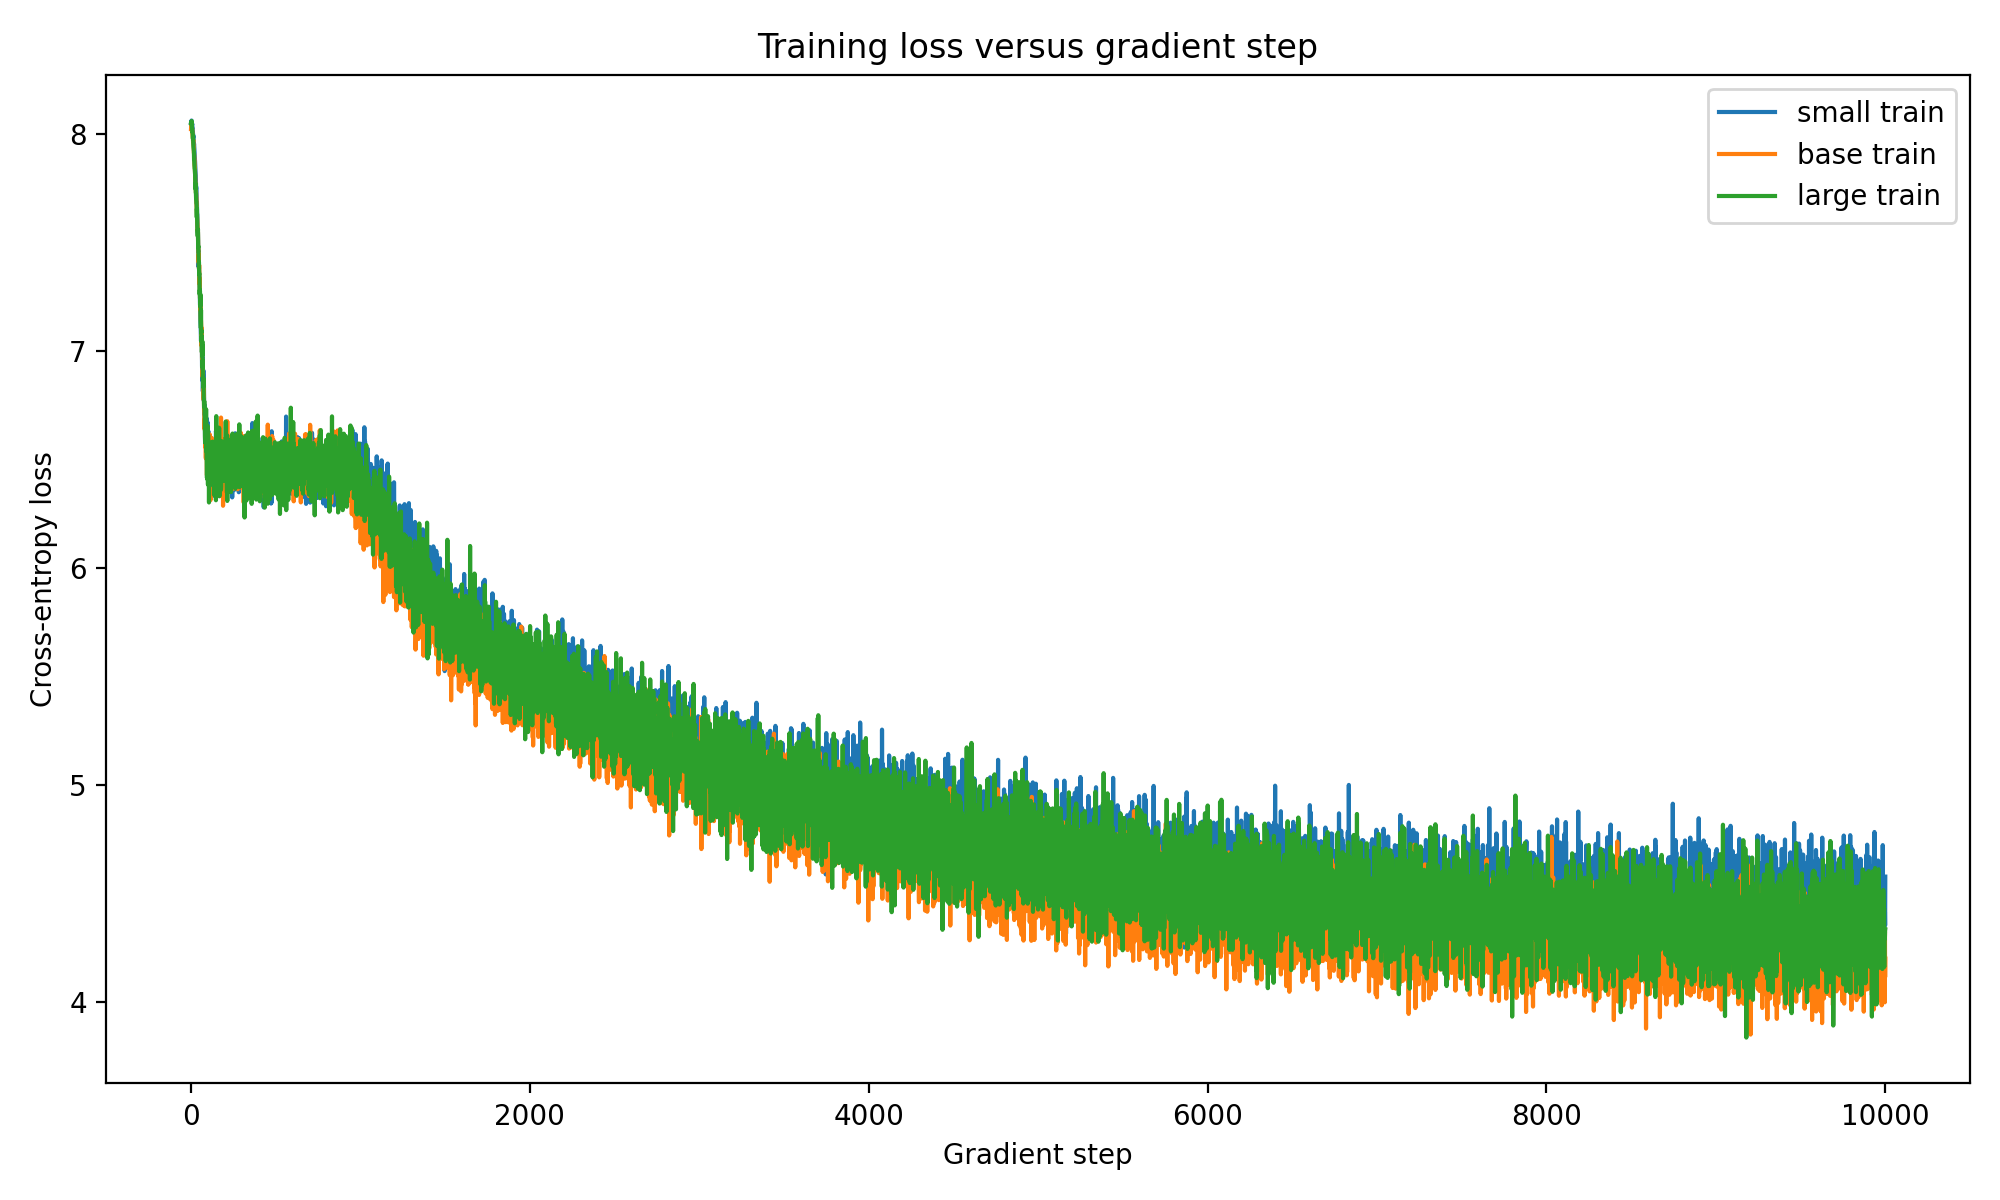

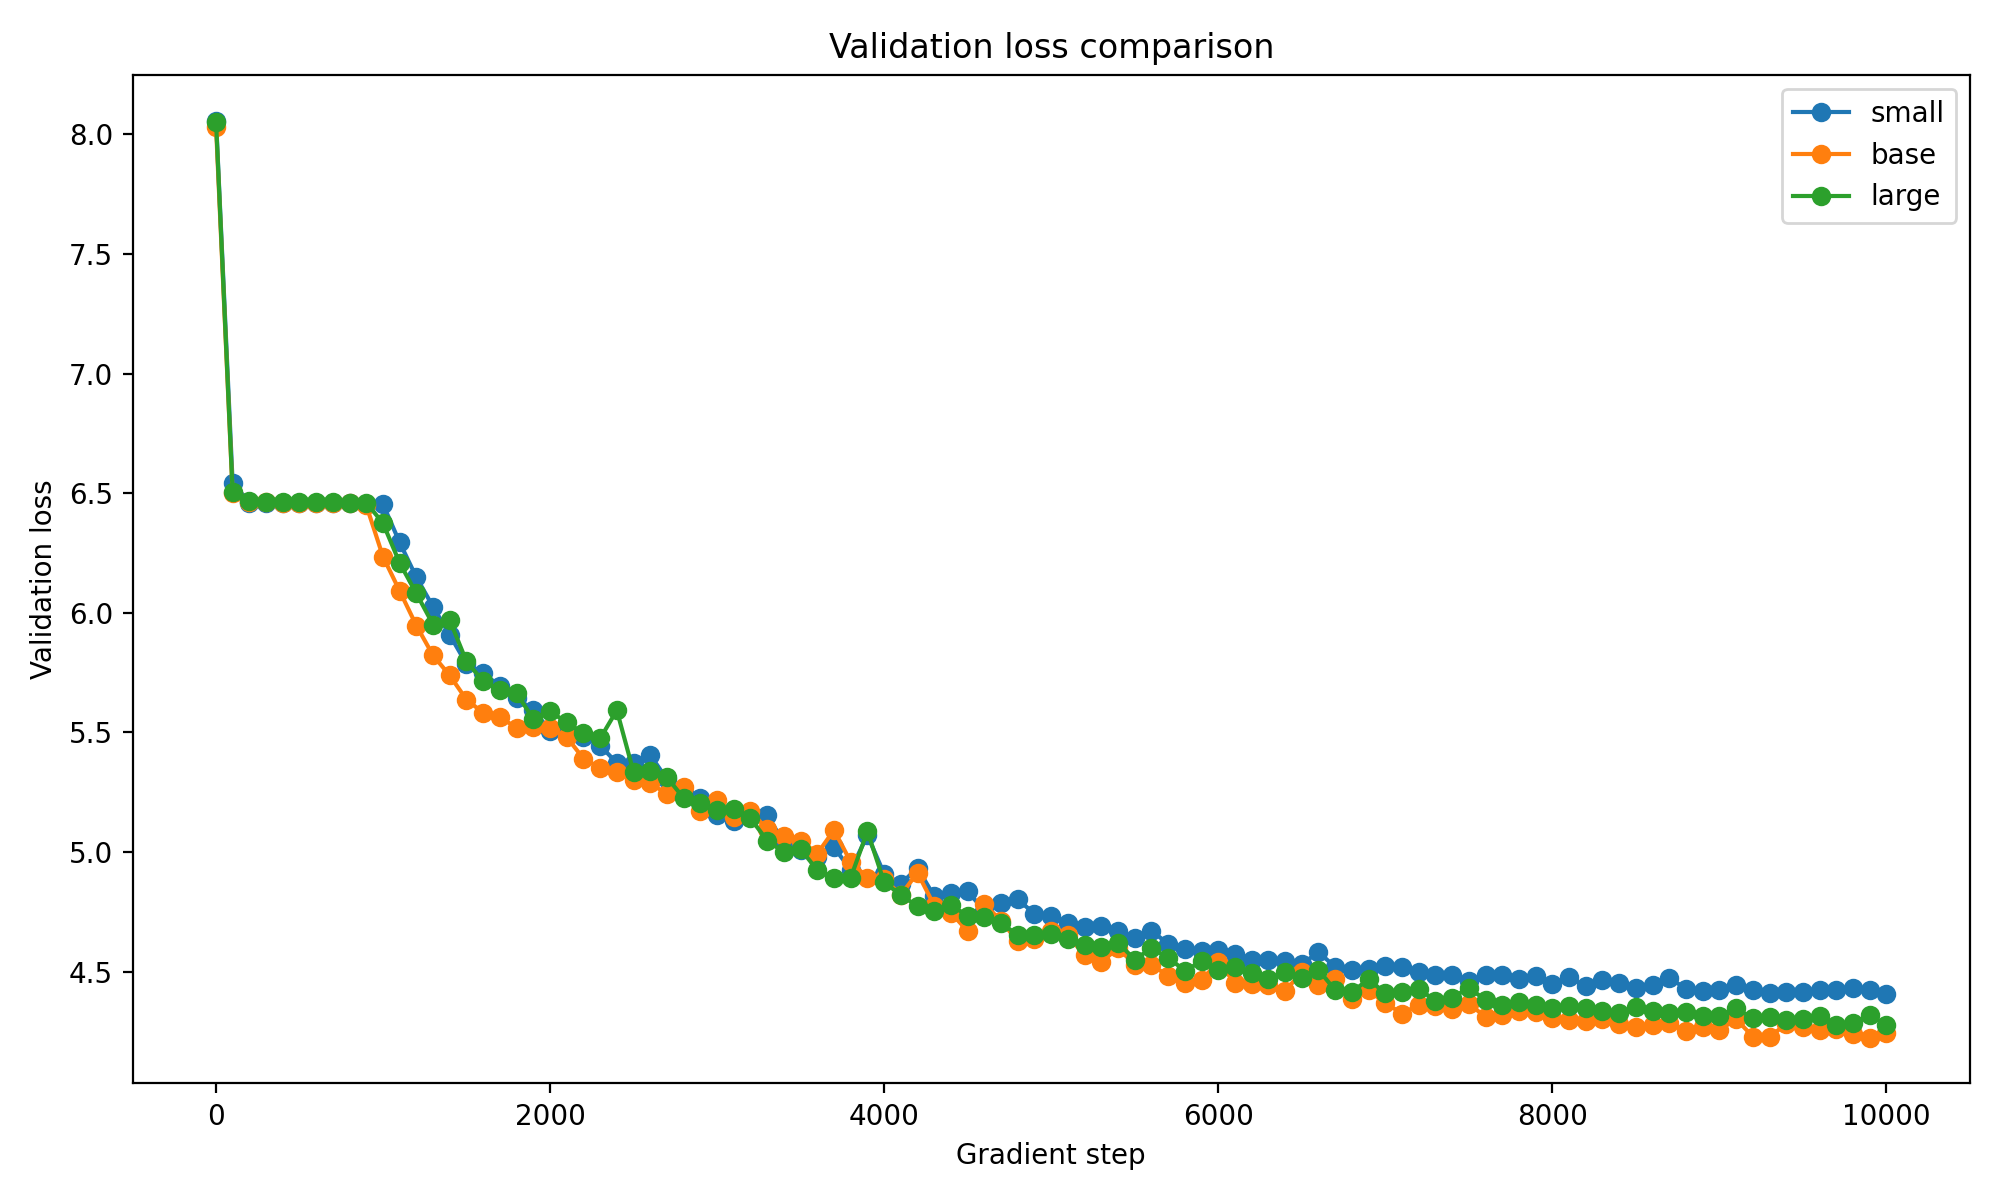

In [27]:
display(Image(run_config.plots / "training_loss_all_models.png"))
display(Image(run_config.plots / "validation_loss_all_models.png"))

The curves drop quickly in the first 100 steps and then flatten. Validation loss improves for all three models, but the differences between them are small under this training budget. That suggests optimization time and token budget were more limiting than raw parameter count in this run.

## (e) Generative Sampling

In [ ]:
SAMPLE_PROMPTS = (
    "An ogre in a swamp",
    "Robert Parr, once Mr. Incredible,",
    "A mammoth, a tiger, and a sloth",
    "Two of Andy's toys",
    "Lightning McQueen was the fastest car in the world.",
)


In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def top_k_filter(logits: torch.Tensor, top_k: int) -> torch.Tensor:
    if top_k <= 0 or top_k >= logits.numel():
        return logits
    values, _ = torch.topk(logits, top_k)
    cutoff = values[..., -1, None]
    return torch.where(logits < cutoff, torch.full_like(logits, float("-inf")), logits)


@torch.no_grad()
def generate_text(
    model: TinyGPT,
    tokenizer: Tokenizer,
    prompt: str,
    device: torch.device,
    max_new_tokens: int = 120,
    temperature: float = 0.9,
    top_k: int = 40,
) -> str:
    ids = tokenizer.encode(prompt).ids
    if not ids:
        ids = [tokenizer.token_to_id(DATA.special_tokens.bos)]
    eos_id = tokenizer.token_to_id(DATA.special_tokens.eos)
    tokens = torch.tensor([ids], dtype=torch.long, device=device)
    for _ in range(max_new_tokens):
        input_tokens = tokens[:, -TRAINING_CONFIG.context_window :]
        logits = model(input_tokens)[:, -1, :] / max(temperature, 1e-5)
        logits = top_k_filter(logits, top_k=top_k)
        probs = F.softmax(logits, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)
        tokens = torch.cat([tokens, next_token], dim=1)
        if eos_id is not None and int(next_token.item()) == eos_id:
            break
    decoded = tokenizer.decode(tokens[0].tolist(), skip_special_tokens=True)
    return decoded


large_config = next(config for config in configs if config.name == "large")
large_model = load_model_for_generation(
    DIRECTORIES.models / "large.pt",
    large_config,
    vocab_size=tokenizer.get_vocab_size(),
    device=device,
)
generations = []
for prompt in TRAINING_CONFIG.sample_prompts:
    generations.append(
        {
            "prompt": prompt,
            "temperature": 0.9,
            "top_k": 40,
            "generated_text": generate_text(
                large_model,
                tokenizer,
                prompt,
                device=device,
                max_new_tokens=120,
                temperature=0.9,
                top_k=40,
            ),
        }
    )

comparison_prompt = "There once was a boy"
experiment_generations = []
for config in configs:
    model = load_model_for_generation(
        DIRECTORIES.models / f"{config.name}.pt",
        config,
        vocab_size=tokenizer.get_vocab_size(),
        device=device,
    )
    experiment_generations.append(
        {
            "model": config.name,
            "prompt": comparison_prompt,
            "generated_text": generate_text(
                model,
                tokenizer,
                comparison_prompt,
                device=device,
                max_new_tokens=100,
                temperature=0.9,
                top_k=40,
            ),
        }
    )

for idx, sample in enumerate(generations, start=1):
    display(Markdown(f"**Sample {idx}. Prompt:** `{sample['prompt']}`"))
    display(Markdown(sample["generated_text"]))

**Sample 1. Prompt:** `This tale begins with an ogre in a swamp. `

This tale begins with an ogre in a swamp. ell is to do your," it I have a great friends.

**Sample 2. Prompt:** `The boring suburban life of Robert Parr, once Mr. Incredible`

The boring suburban life of Robert Parr, once Mr. Incredible, but I want to do it?" she knew that he would always have to be careful to make more friend. The moral The bird became a nice girl and had lots She had best friends. At her mom and

**Sample 3. Prompt:** `Manny the mammoth befriended a sloth and a sabre toothed tiger`

Manny the mammoth befriended a sloth and a sabre toothed tiger a big tree and put them for a new ball. She tried to help them on the park and said, "I get me your?" A dog was so happy. She was surprised but because the water was gone that it and they had a magic time. The little bird was happy. She started to play with the big bird.
The bug. Tom was happy and played together.
After the big dog was gone.
The bird was important and had lots From that the big ball were scared of her.

**Sample 4. Prompt:** `Woody and Buzz Lightyear, two of Andy's toys had come alive!`

Woody and Buzz Lightyear, two of Andy's toys had come alive! The end.

**Sample 5. Prompt:** `There was no car faster than Lightning McQueen`

There was no car faster than Lightning McQueenfee, Mia was time. She looked for them to go to her own day, he saw a big big dog came to the tree. He wanted to find him. He said but she said, "Hello, It's you have to play with the rock." They all laughed together and was surprised. They played all day. They both all day.

In [33]:
new_generations = []
for prompt in ["Once upon a time", "There was once a fairy"]:
    new_generations.append(
        {
            "prompt": prompt,
            "temperature": 0.5,
            "top_k": 10,
            "generated_text": generate_text(
                large_model,
                tokenizer,
                prompt,
                device=device,
                max_new_tokens=120,
                temperature=0.9,
                top_k=40,
            ),
        }
    )

for idx, sample in enumerate(new_generations):
    display(Markdown(f"**Sample {idx}. Prompt:** `{sample['prompt']}`"))
    display(Markdown(sample["generated_text"]))

**Sample 0. Prompt:** `Once upon a time`

Once upon a time there was a little boy named Tim. Max was very happy with his toys, and she had friends. One that Sue and Sam wanted to see it. They went to take many friends all day.
One day, Lucy saw a big red girl and her friends. Spot found a big dog who wanted to go up the woods. Tom was excited and played with his friends. Tim was sad. They loved to play with his mom. Tim felt sad because he could always go down and eat his mom. She went to the park and the other bug and said, "Oucy!" They both are very happy. So, then, Tim found a little girl in the park all

**Sample 1. Prompt:** `There was once a fairy`

There was once a fairy named Amy looked at the park and said, "That's no I play with a lot you, Tim smiled and Sue, but she went to the box and saw a tree. They both saw a new red red box, and all unexpected happened. Tim felt so excited. "Can He wanted to play with her house so much fun for the tree. In Max said, "I will be! Thank this Tim. Can I get to get it?" The fish was sad and said, "No, I will help your good you go you want to the rock." The bird tried to the big ball. Tim was happy and said, "I look to go fast to go to help a